In [49]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist

# -----------------------------
# Parameters
# -----------------------------
n_points = 10000          # number of points
max_dim = 100           # maximum dimension
dim_values = np.arange(1, max_dim + 1)

min_dists = []
max_dists = []
mean_dists = []
std_dists = []

# -----------------------------
# Loop over dimensions
# -----------------------------
for p in dim_values:
    
    # Generate n_points in p dimensions
    X = np.random.randn(n_points, p)  # mean=0, std=1
    
    # Compute all pairwise Euclidean distances
    distances = pdist(X, metric='euclidean')
    
    # Store statistics
    min_dists.append(np.min(distances))
    max_dists.append(np.max(distances))
    mean_dists.append(np.mean(distances))
    std_dists.append(np.std(distances))

min_dists = np.array(min_dists)
max_dists = np.array(max_dists)
mean_dists = np.array(mean_dists)
std_dists = np.array(std_dists)


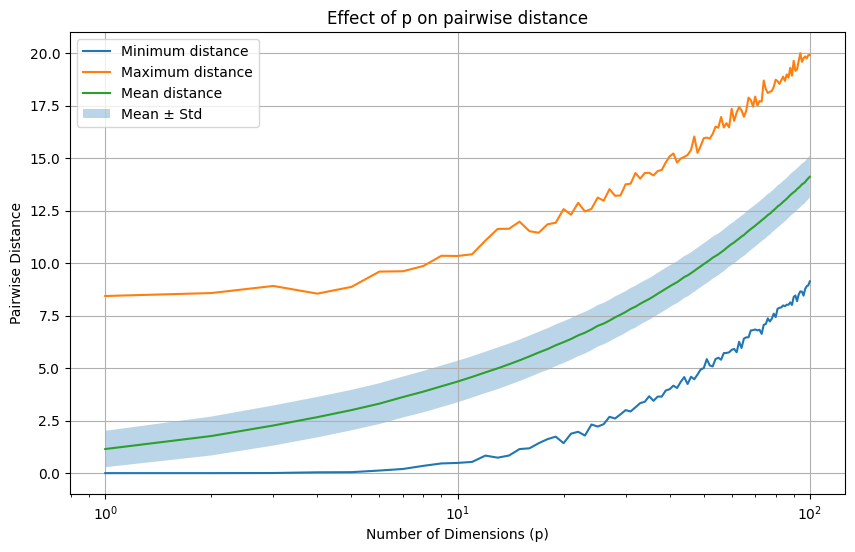

In [50]:
plt.figure(figsize=(10, 6))

plt.semilogx(dim_values, min_dists, label='Minimum distance')
plt.semilogx(dim_values, max_dists, label='Maximum distance')
plt.semilogx(dim_values, mean_dists, label='Mean distance')
plt.fill_between(dim_values,
                 mean_dists - std_dists,
                 mean_dists + std_dists,
                 alpha=0.3,
                 label='Mean ± Std')

plt.xlabel('Number of Dimensions (p)')
plt.ylabel('Pairwise Distance')
plt.title('Effect of p on pairwise distance')
plt.legend()
plt.grid(True)
plt.show()

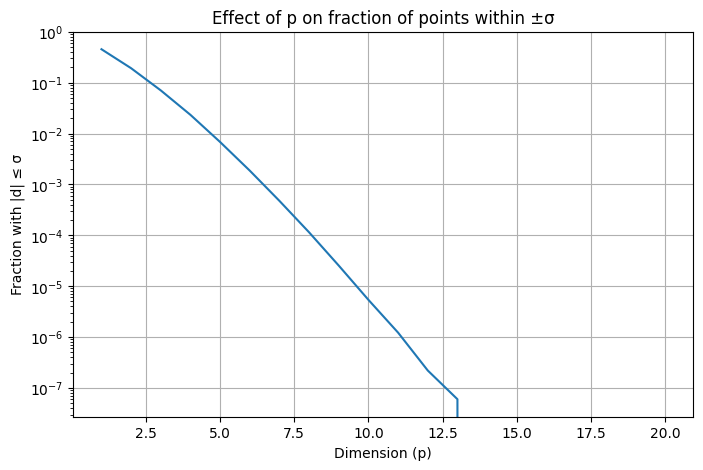

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist

# -----------------------------
# Parameters
# -----------------------------
n_points = 10000
max_dim = 20
dim_values2 = np.arange(1, max_dim + 1)

# Generate all dimensions at once
X_full = np.random.randn(n_points, max_dim)

fractions = []

# -----------------------------
# Loop over dimensions
# -----------------------------
for p in dim_values2:
    
    # Use first p coordinates
    X = X_full[:, :p]
    
    # Pairwise distances
    distances = pdist(X, metric='euclidean')
    
    # Statistics
    std_dist = np.std(distances)
    
    within = distances <= std_dist
    
    fraction = np.mean(within)
    fractions.append(fraction)

fractions = np.array(fractions)

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(8,5))
plt.semilogy(dim_values2, fractions)
plt.xlabel("Dimension (p)")
plt.ylabel("Fraction with |d| ≤ σ")
plt.title("Effect of p on fraction of points within ±σ")
plt.grid(True)
plt.show()

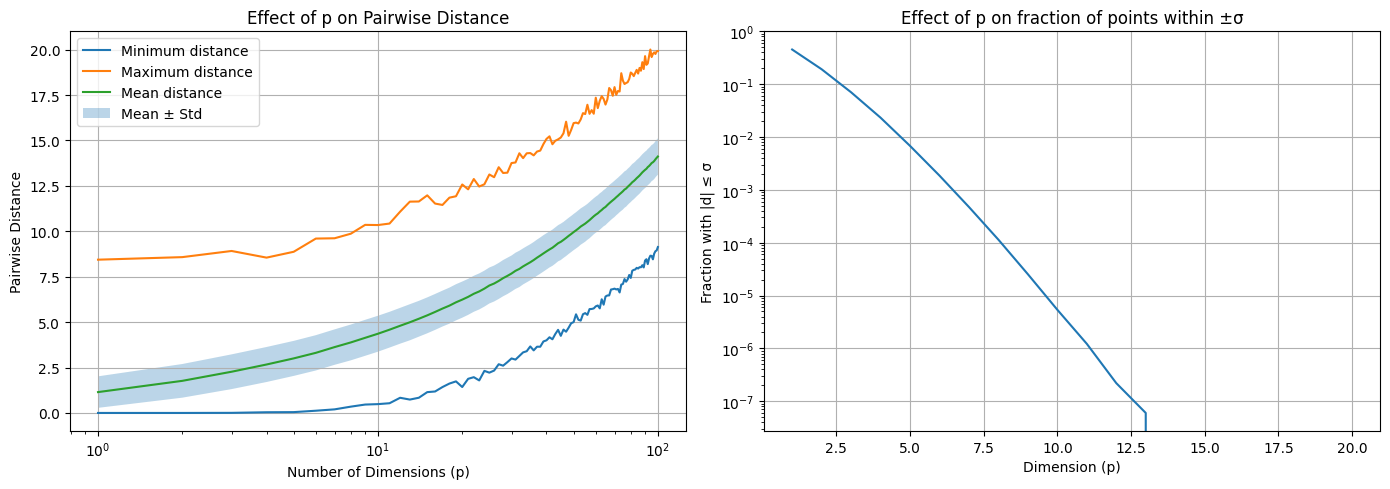

In [52]:
import matplotlib.pyplot as plt
import textwrap

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]

ax1.semilogx(dim_values, min_dists, label='Minimum distance')
ax1.semilogx(dim_values, max_dists, label='Maximum distance')
ax1.semilogx(dim_values, mean_dists, label='Mean distance')
ax1.fill_between(dim_values,
                 mean_dists - std_dists,
                 mean_dists + std_dists,
                 alpha=0.3,
                 label='Mean ± Std')

ax1.set_xlabel('Number of Dimensions (p)')
ax1.set_ylabel('Pairwise Distance')
ax1.set_title('Effect of p on Pairwise Distance')
ax1.legend()
ax1.grid(True)

ax2 = axes[1]

ax2.semilogy(dim_values2, fractions)
ax2.set_xlabel("Dimension (p)")
ax2.set_ylabel("Fraction with |d| ≤ σ")
ax2.set_title("Effect of p on fraction of points within ±σ")
ax2.grid(True)

plt.tight_layout()
plt.show()
fig.savefig('CoD.png')

# Summary
![Effect of p on pairwise distance and the fraction of points within 1 standard deviation](CoD.png)
*Figure 1. Recreated Figure 2a (left) and 2b (right) from Altman and Krzywinski (2018). (Left) Pairwise distance for 10,000 normally distributed points in \( p \) dimensions. As dimensionality increases, pairwise distance increases. (Right) Fraction of points within one standard deviation as a function of \( p \). As dimensionality increases, the fraction drops rapidly. Viewing these plots reveals that the increasing dimensionality makes it more difficult to draw meaningful conclusions from distances.*

Code produced with the assistance of ChatGPT.